# Lecture 3 · Exercises

Code for [exercises.md](exercises.md)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../../coding_tasks/Data/Out_Data")
rng = np.random.default_rng(1234)

### Helpers

In [2]:
def simple_ra(n, prob):
    """Every unit enters independently with probability prob, like randomizr::simple_ra."""
    return (rng.random(n) < prob).astype(int)

---

## Exercise 3.1 · Sampling strategies

No code, see [exercises.md](exercises.md)

---

## Exercise 3.2 · Referendum survey

### Data

In [3]:
df = pd.read_csv(DATA / "lecture3_survey.csv")
print(df.shape)
df.head()

(100000, 6)


,id,gender,car,municipality,party,support
0,1,male,Yes,2,The Liberals (FDP),0
1,2,female,Yes,1207,Swiss People's Party (SVP),1
2,3,female,No,426,Swiss People's Party (SVP),1
3,4,female,Yes,1552,The Center (Mitte),1
4,5,male,Yes,489,The Liberals (FDP),0


The slide calls the file `lecture3_sampling.csv` and says car drivers have the value 1. In the data the file is `lecture3_survey.csv` and `car` is Yes/No.

In [4]:
df["car"].value_counts()

car
No     50018
Yes    49982
Name: count, dtype: int64

### 1 · Population mean

In [5]:
pop_mean = df["support"].mean()
pop_mean

np.float64(0.5984)

Support by group (not asked, but it explains parts 3 and 5)

In [6]:
pd.concat(
    {col: df.groupby(col)["support"].agg(["mean", "size"]) for col in ["car", "gender", "party"]}
).round(3)

mean   size
car    No                          0.724  50018
       Yes                         0.472  49982
gender female                      0.787  50016
       male                        0.410  49984
party  Social Democrats (SP)       0.773  24761
       Swiss People's Party (SVP)  0.419  25101
       The Center (Mitte)          0.661  24955
       The Liberals (FDP)          0.543  25183

### 2 · Simple random sample

In [7]:
df["sample"] = simple_ra(len(df), prob=0.01)
df["sample"].value_counts()

sample
0    99025
1      975
Name: count, dtype: int64

In [8]:
srs_mean = df.loc[df["sample"] == 1, "support"].mean()
print(f"n = {df['sample'].sum()}, mean support = {srs_mean:.4f}, population = {pop_mean:.4f}")

n = 975, mean support = 0.6195, population = 0.5984


Expected sampling noise for a share with n = 1,000

In [9]:
se = np.sqrt(pop_mean * (1 - pop_mean) / 1000)
print(f"SE = {se:.4f}, about 95% of estimates within {pop_mean - 2 * se:.3f} to {pop_mean + 2 * se:.3f}")

SE = 0.0155, about 95% of estimates within 0.567 to 0.629


### 3 · Car drivers only

1,000 out of the car drivers means a probability of 1000 / 49,982 ≈ 0.02. The R solution uses 0.01 and ends up with about 500 people.

In [10]:
df_car = df[df["car"] == "Yes"].copy()
df_car["sample"] = simple_ra(len(df_car), prob=1000 / len(df_car))
car_n = df_car["sample"].sum()
car_mean = df_car.loc[df_car["sample"] == 1, "support"].mean()
print(f"n = {car_n}, mean support = {car_mean:.4f}, population = {pop_mean:.4f}")

n = 971, mean support = 0.4686, population = 0.5984


A larger sample from the same list does not help (Literary Digest)

In [11]:
for n in [1_000, 10_000, len(df_car)]:
    idx = rng.choice(len(df_car), size=n, replace=False)
    print(f"n = {n:>6}: mean support = {df_car['support'].iloc[idx].mean():.4f}")

n =   1000: mean support = 0.4800
n =  10000: mean support = 0.4729
n =  49982: mean support = 0.4724


### 4 · Cluster sample of 20 municipalities

In [12]:
sampled_clusters = rng.choice(df["municipality"].unique(), size=20, replace=False)
df_cluster = df[df["municipality"].isin(sampled_clusters)]
print(f"n = {len(df_cluster)}, mean support = {df_cluster['support'].mean():.4f}, population = {pop_mean:.4f}")

n = 1006, mean support = 0.6083, population = 0.5984


Are the municipalities alike? Spread of the municipality means vs. pure sampling noise with ~50 people each

In [13]:
muni = df.groupby("municipality")["support"].agg(["mean", "size"])
noise = np.sqrt(pop_mean * (1 - pop_mean) / muni["size"].mean())
print(f"{len(muni)} municipalities, {muni['size'].mean():.0f} people on average")
print(f"SD of municipality means:            {muni['mean'].std():.4f}")
print(f"SD expected from sampling noise only: {noise:.4f}")

2000 municipalities, 50 people on average
SD of municipality means:            0.0691
SD expected from sampling noise only: 0.0693


### 5 · Stratified sample by car

In [14]:
df_car = df[df["car"] == "Yes"].copy()
df_nocar = df[df["car"] == "No"].copy()
df_car["sample"] = simple_ra(len(df_car), prob=0.01)
df_nocar["sample"] = simple_ra(len(df_nocar), prob=0.01)

df_strat = pd.concat([df_car, df_nocar], ignore_index=True)
df_strat = df_strat[df_strat["sample"] == 1]
print(f"n = {len(df_strat)}, mean support = {df_strat['support'].mean():.4f}, population = {pop_mean:.4f}")
df_strat["car"].value_counts()

n = 954, mean support = 0.6101, population = 0.5984


car
No     485
Yes    469
Name: count, dtype: int64

### Summary of one draw per design

In [15]:
pd.DataFrame(
    {
        "n": [len(df), df["sample"].sum(), car_n, len(df_cluster), len(df_strat)],
        "mean support": [pop_mean, srs_mean, car_mean, df_cluster["support"].mean(), df_strat["support"].mean()],
    },
    index=["population", "2 · simple random", "3 · car drivers", "4 · 20 municipalities", "5 · stratified by car"],
).round(4)

,n,mean support
population,100000,0.5984
2 · simple random,975,0.6195
3 · car drivers,971,0.4686
4 · 20 municipalities,1006,0.6083
5 · stratified by car,954,0.6101


---

## Beyond the exercise · 2,000 samples per design

One draw per design cannot tell bias from luck. Repeating each design 2,000 times shows both:

- **bias** = mean of the 2,000 estimates − population mean
- **standard error** = standard deviation of the 2,000 estimates

In [16]:
support = df["support"].to_numpy()
is_car = (df["car"] == "Yes").to_numpy()
is_female = (df["gender"] == "female").to_numpy()
muni_sum = df.groupby("municipality")["support"].sum()
muni_n = df.groupby("municipality")["support"].size()
REPS = 2_000


def srs(y, n):
    return y[rng.choice(len(y), size=n, replace=False)].mean()


def stratified(y, groups, n):
    """Proportional allocation: each stratum gets n times its population share."""
    parts = [y[g][rng.choice(g.sum(), size=round(n * g.mean()), replace=False)] for g in groups]
    return np.concatenate(parts).mean()


def cluster(k):
    chosen = rng.choice(muni_sum.index, size=k, replace=False)
    return muni_sum[chosen].sum() / muni_n[chosen].sum()


designs = {
    "simple random": lambda: srs(support, 1000),
    "car drivers only": lambda: srs(support[is_car], 1000),
    "20 municipalities": lambda: cluster(20),
    "stratified by car": lambda: stratified(support, [is_car, ~is_car], 1000),
    "stratified by gender": lambda: stratified(support, [is_female, ~is_female], 1000),
}
sims = {name: np.array([draw() for _ in range(REPS)]) for name, draw in designs.items()}

In [17]:
pd.DataFrame(
    {
        "mean estimate": {k: v.mean() for k, v in sims.items()},
        "bias": {k: v.mean() - pop_mean for k, v in sims.items()},
        "standard error": {k: v.std() for k, v in sims.items()},
    }
).round(4)

,mean estimate,bias,standard error
simple random,0.5984,-0.0000,0.0153
car drivers only,0.4722,-0.1262,0.0157
20 municipalities,0.5982,-0.0002,0.0150
stratified by car,0.5988,0.0004,0.0151
stratified by gender,0.5979,-0.0005,0.0141


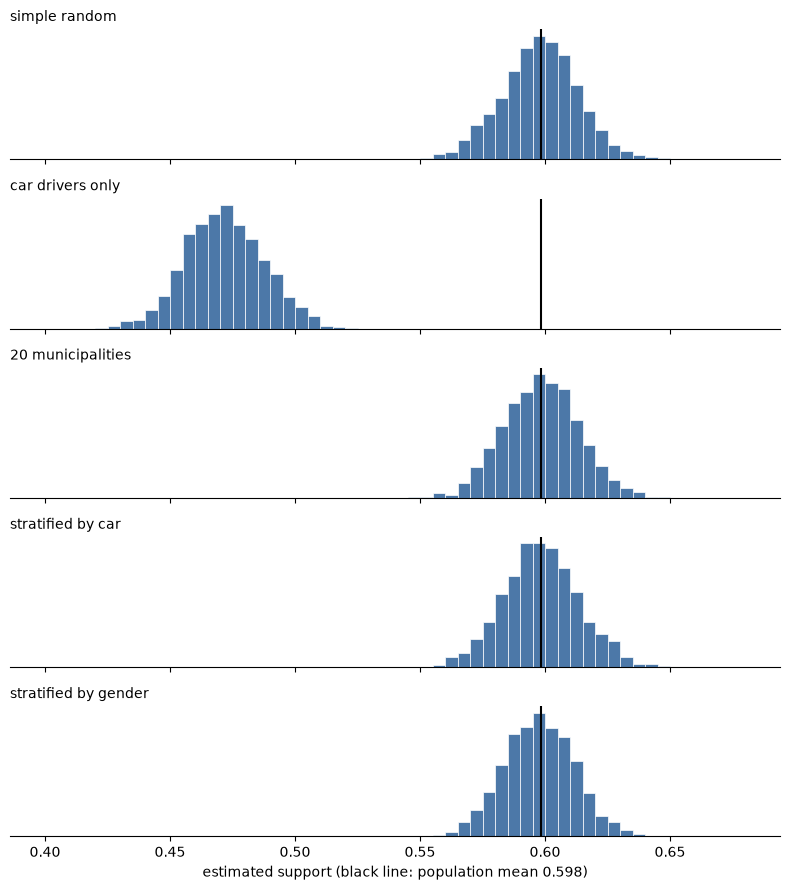

In [18]:
fig, axes = plt.subplots(len(sims), 1, figsize=(8, 9), sharex=True)
bins = np.arange(0.40, 0.68, 0.005)
for ax, (name, est) in zip(axes, sims.items()):
    ax.hist(est, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.5)
    ax.axvline(pop_mean, color="black", linewidth=1.5)
    ax.set_title(name, loc="left", fontsize=10)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
axes[-1].set_xlabel("estimated support (black line: population mean 0.598)")
plt.tight_layout()
plt.show()

- Car drivers only: the whole distribution sits around 0.47. Every single sample misses, no matter how lucky.
- The other designs are centred on the population mean. They differ only in spread.
- The cluster sample is as precise as the simple random sample here, because the municipalities do not differ (part 4). With real municipalities (city vs. countryside) it would be wider.
- Stratifying helps a little. By gender a bit more than by car, because support differs more between women and men (79% vs. 41%) than between car owners and others (47% vs. 72%).